In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [46]:
df = pd.read_stata('Mexico-2023-full-data.dta')
df.columns.tolist()

['idstd',
 'id',
 'a4a',
 'a6a',
 'a2',
 'a1c',
 'competition_select',
 'tax_select',
 'vat_applicable',
 'a4b_v4',
 'a0',
 'a3a',
 'a6b',
 'a6c',
 'a7',
 'panel',
 'a1a',
 'a14d',
 'a14m',
 'a14y',
 'a14h',
 'a14min',
 'ic1',
 'a20y',
 'a20m',
 'a20d',
 'a1',
 'a7a',
 'a7b',
 'a11',
 'a7c',
 'a9',
 'b1',
 'b1x',
 'b3a',
 'b2a',
 'b2b',
 'b2c',
 'b2d',
 'b4',
 'b4a',
 'b5',
 'b6',
 'b6b',
 'b7',
 'b7a',
 'b8',
 'b8x',
 'c3',
 'c4',
 'c5',
 'c31',
 'c32',
 'c6',
 'c7',
 'c8a',
 'c8b',
 'c9a',
 'c9b',
 'c10',
 'c11',
 'c12',
 'c13',
 'c14',
 'c33',
 'c34',
 'c34b',
 'c34bx',
 'c152',
 'c162',
 'c172',
 'c35a',
 'c35b',
 'c22b',
 'c36',
 'c37',
 'c38',
 'c39',
 'c40a',
 'c40b',
 'c41a',
 'c41b',
 'c42',
 'c30a',
 'd1a1a',
 'd1a1x',
 'd1a6a',
 'd1a6b',
 'd1a6c',
 'd1a6cx',
 'd1a3',
 'd2',
 'd2x',
 'd2a1',
 'd2a1x',
 'n3',
 'n3x',
 'd3a',
 'd3b',
 'd3c',
 'd31x',
 'd32',
 'd4a',
 'd4b',
 'd33a',
 'd33b',
 'd34',
 'd35',
 'd36a',
 'd36b',
 'd37',
 'd8',
 'd12a',
 'd12b',
 'd13',
 'd38x',
 'd

In [55]:
cols = ['d2', 'l1', 'h1', 'k3bc', 'd3a', 'd3b', 'd3c', 'e2b']
df[cols]

,d2,l1,h1,k3bc,d3a,d3b,d3c,e2b
0,30700000,53,No,10,100,0,0,2
1,29000000,22,No,10,100,0,0,Don't know (spontaneous)
2,43000000,107,No,5,100,0,0,Don't know (spontaneous)
3,135000000,270,No,15,100,0,0,Too many to count
4,6000000,15,No,10,100,0,0,Too many to count
...,...,...,...,...,...,...,...,...
1317,5000000,5,No,0,100,0,0,Too many to count
1318,15000000,8,No,10,100,0,0,Don't know (spontaneous)
1319,16000000,12,No,10,100,0,0,Don't know (spontaneous)
1320,13000000,11,Yes,0,100,0,0,Too many to count


## 1. Deleting extra columns

In [62]:
df_clean = pd.DataFrame()

df_clean.replace([-9, -4], np.nan, inplace=True)

df_clean['sales'] = df['d2']
df_clean['employees'] = df['l1']
df_clean['training'] = df['h1'].map({'Yes': 1, 'No': 0})
df_clean['financing_obtained'] = (df['k3bc'] > 0).astype(int)
df_clean['exporter'] = (
    (df['d3b'].fillna(0) > 0) |
    (df['d3c'].fillna(0) > 0)
).astype(int)
df_clean['e2b_clean'] = pd.to_numeric(df['e2b'], errors='coerce')
df_clean['competition_level'] = (df['e2b_clean'] > 5).astype(int)

df_clean

,sales,employees,training,financing_obtained,exporter,e2b_clean,competition_level
0,30700000,53,0.0,1,0,2.0,0
1,29000000,22,0.0,1,0,NaN,0
2,43000000,107,0.0,1,0,NaN,0
3,135000000,270,0.0,1,0,NaN,0
4,6000000,15,0.0,1,0,NaN,0
...,...,...,...,...,...,...,...
1317,5000000,5,0.0,0,0,NaN,0
1318,15000000,8,0.0,1,0,NaN,0
1319,16000000,12,0.0,1,0,NaN,0
1320,13000000,11,1.0,0,0,NaN,0


In [63]:
df_clean.isna().sum()

sales                   0
employees               0
training                2
financing_obtained      0
exporter                0
e2b_clean             829
competition_level       0
dtype: int64

## 2. Checking for nulls

In [68]:
df_model = df_clean.dropna(subset=['training'])
df_model.isna().sum()

sales                   0
employees               0
training                0
financing_obtained      0
exporter                0
e2b_clean             827
competition_level       0
dtype: int64

## 3. Variables independientes y variable dependiente

In [69]:
y = df_model['sales']

X = df_model[['employees', 'training', 'financing_obtained', 'exporter', 'competition_level']]

In [70]:
X.head()

,employees,training,financing_obtained,exporter,competition_level
0,53,0.0,1,0,0
1,22,0.0,1,0,0
2,107,0.0,1,0,0
3,270,0.0,1,0,0
4,15,0.0,1,0,0


## 4. Modelo

In [71]:
#Ajustar el modelo de regresión múltiple
model = LinearRegression() 
model.fit(X, y) #Entrenando el modelo 
y_pred = model.predict(X)
#y_pred

## 5. Métricas

In [72]:
#Metricas estadísticas
mse = mean_squared_error(y, y_pred) #Error de la media cuadrática
r2 = r2_score(y, y_pred) #varianza

In [73]:
print('Valor de intersección : ', model.intercept_)
print('Coeficientes: ', model.coef_)
print('Error cuadrático medio', mse)
print('Varianza: ', r2)

Valor de intersección :  -3506755.034596935
Coeficientes:  [  1117932.77325825  25329014.32049064  -1665083.43175002
 -11244336.53153178  11932052.94897565]
Error cuadrático medio 5799207929609763.0
Varianza:  0.7231782976003609


## 6. Gráfica

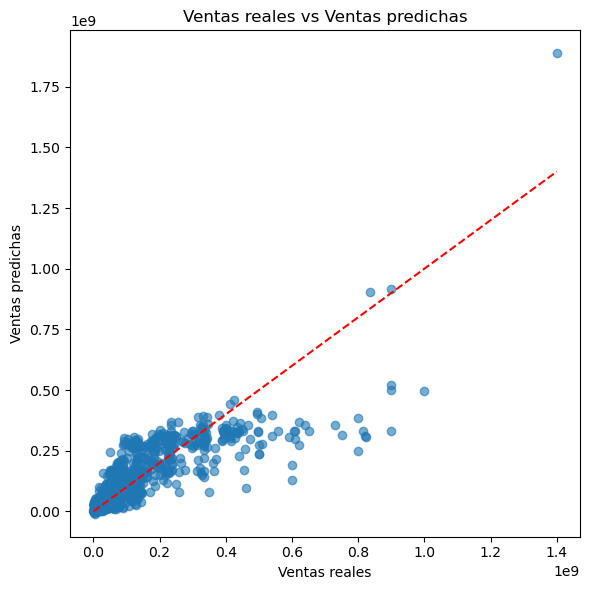

In [74]:
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Ventas reales')
plt.ylabel('Ventas predichas')
plt.title('Ventas reales vs Ventas predichas')
plt.tight_layout()
plt.show()

## 7. Conclusiones
El modelo de regresión lineal explica aproximadamente el 72.3% de la variabilidad en las ventas, lo que indica una capacidad explicativa buena para datos económicos a nivel país.
De acuerdo con los coeficientes estimados, la variable training es la que mayor impacto tiene sobre las ventas, seguida por el nivel de competencia. Esto sugiere que el capital humano y el entorno competitivo son factores clave en el desempeño económico de las empresas.